***Emotion Classification using LSTM***
**Project Overview**

This notebook implements an Emotion Classification model using Natural Language Processing (NLP) and a Long Short-Term Memory (LSTM) neural network.

The goal of this project is to classify text into different emotion categories such as joy, sadness, anger, fear, love, and surprise. The notebook demonstrates a complete deep learning pipeline starting from raw text data to a trained emotion classification model.

**Workflow**

The following steps are performed in this notebook:

**Load the Dataset :** Import training, validation, and test datasets.

**Text Preprocessing :** Clean and prepare text data for modeling.

**Tokenization & Padding :** Convert text into numerical sequences.

**Label Encoding :** Transform emotion labels into numerical format.

**Model Building :** Construct an LSTM based deep learning model.

**Model Training :** Train the model with validation monitoring.

**Model Evaluation :** Evaluate the model performance on unseen test data.

**Model Architecture**

The model consists of the following layers:

**Embedding Layer :** Converts words into dense vector representations

**Bidirectional LSTM :** Captures contextual relationships in text

**Dropout Layers :** Prevent overfitting (Because we don't have plenty of data)

**Dense Layers :** Perform final emotion classification

**Objective**

The purpose of this notebook is to demonstrate how deep learning techniques can be applied to NLP tasks for accurate emotion detection from text data.

In [61]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Add src folder to path if preprocessing.py is there
sys.path.append('../src')
from preprocessing import load_data 

In [62]:
train = load_data('../data/train.txt')
val   = load_data('../data/val.txt')
test  = load_data('../data/test.txt')

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

# Example of the data
train.head()

Train shape: (16000, 2)
Validation shape: (2000, 2)
Test shape: (2000, 2)


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [63]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train['label'])
y_val   = label_encoder.transform(val['label'])
y_test  = label_encoder.transform(test['label'])

num_classes = len(label_encoder.classes_)

# Convert to one-hot
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val, num_classes=num_classes)
y_test_cat  = to_categorical(y_test, num_classes=num_classes)

print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)

Classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']
Number of classes: 6


In [84]:
max_words = 15000
max_len = 150  # max sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train['text'])

X_train_seq = tokenizer.texts_to_sequences(train['text'])
X_val_seq   = tokenizer.texts_to_sequences(val['text'])
X_test_seq  = tokenizer.texts_to_sequences(test['text'])

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')
print("Shape of X_train_pad:", X_train_pad.shape)
print("Shape of y_train_cat:", y_train_cat.shape)

Shape of X_train_pad: (16000, 150)
Shape of y_train_cat: (16000, 6)


In [85]:
embedding_dim = 128

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.7),
    Dense(32, activation='relu'),
    Dropout(0.7),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_15                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [86]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - accuracy: 0.3223 - loss: 1.6053 - val_accuracy: 0.4805 - val_loss: 1.4770
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.5179 - loss: 1.1720 - val_accuracy: 0.6975 - val_loss: 0.8335
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.6833 - loss: 0.8279 - val_accuracy: 0.7445 - val_loss: 0.7794
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.7319 - loss: 0.6972 - val_accuracy: 0.7650 - val_loss: 0.7537
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.7841 - loss: 0.5854 - val_accuracy: 0.8390 - val_loss: 0.5992
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.8174 - loss: 0.4943 - val_accuracy: 0.8535 - val_loss: 0.5572
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.8436 - loss: 0.4334 - val_accuracy: 0.8575 - val_loss: 0.5438
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.8545 - loss: 0.3990 - 

In [87]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test_cat)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8485 - loss: 0.5223
Test Accuracy: 84.85%
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
              precision    recall  f1-score   support

       anger       0.90      0.85      0.87       275
        fear       0.68      0.92      0.78       224
         joy       0.87      0.93      0.90       695
        love       0.65      0.70      0.67       159
     sadness       0.96      0.86      0.91       581
    surprise       0.00      0.00      0.00        66

    accuracy                           0.85      2000
   macro avg       0.68      0.71      0.69      2000
weighted avg       0.83      0.85      0.84      2000



c:\Users\PMLS\Emotion-Classification-NLP-Comparison\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PMLS\Emotion-Classification-NLP-Comparison\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PMLS\Emotion-Classification-NLP-Comparison\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

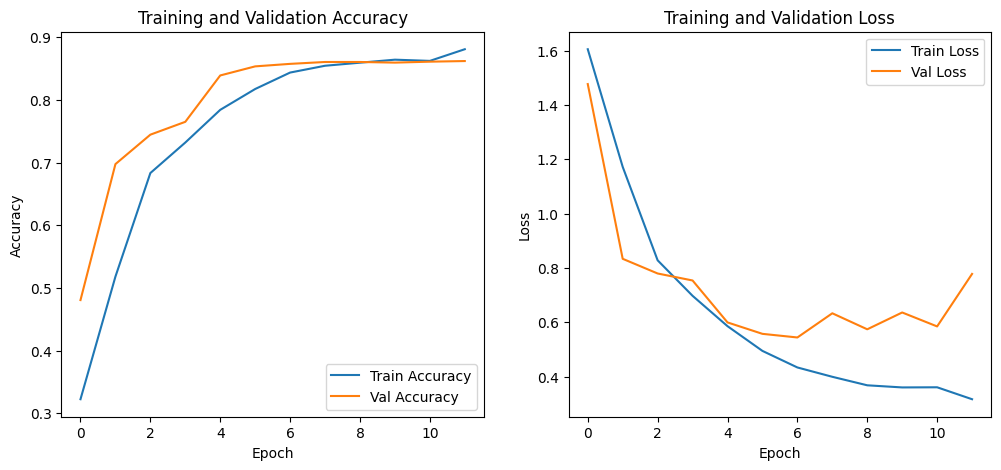

In [88]:
model.save('../models/lstm_emotion_classifier.h5')

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [89]:
import numpy as np

# choose a few random examples from the test set
n = 5
idx = np.random.choice(test.index, size=n, replace=False)
samples = test.loc[idx]

def predict_texts(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    pad = pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
    probs = model.predict(pad)
    preds = np.argmax(probs, axis=1)
    return preds, probs

preds, probs = predict_texts(samples['text'].tolist())

# report
for i, (txt, true_lbl, pred, prob_row) in enumerate(zip(
        samples['text'], samples['label'], preds, probs)):
    print(f"Example {i+1}:")
    print(" text   :", txt)
    print(" true   :", true_lbl)
    print(" pred   :", label_encoder.inverse_transform([pred])[0],
          f"(conf {prob_row[pred]:.3f})")
    print('-'*60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
Example 1:
 text   : i ignore this voice as well knowing by now it doesn t matter if i feel humiliated by what you request of me i like that feeling i welcome that flushed hot feeling of embarrassment that you can arouse in me
 true   : sadness
 pred   : joy (conf 0.934)
------------------------------------------------------------
Example 2:
 text   : i feel appalled right now
 true   : anger
 pred   : anger (conf 0.743)
------------------------------------------------------------
Example 3:
 text   : i dont want flowers or candy but the kind of guy that knows i like thinly sliced limes in my mineral water because it makes me feel glamorous and is humored by how pretentious that is
 true   : joy
 pred   : joy (conf 0.998)
------------------------------------------------------------
Example 4:
 text   : i feel blessed beyond blessed to share my life with you each week
 true   : love
 pred   : love (conf 0.658)
--------------------------------------